In [1]:
import numpy as np
import os
import scipy.io

In [2]:
import tarfile
import numpy as np 

In [3]:
labelsn = scipy.io.loadmat("imagelabels.mat")
labelsn = labelsn["labels"]
labelsn = labelsn[0]
for i in range(len(labelsn)):
  labelsn[i] = labelsn[i] - 1

In [4]:

import cv2
import tensorflow.compat.v1 as tf
tf.disable_v2_behavior()
from keras.utils import to_categorical
from sklearn.model_selection import train_test_split

Instructions for updating:
non-resource variables are not supported in the long term


In [5]:
train_x = []
train_y = []
dir = "flowers/"
for imgs in os.listdir(dir):
    imgnum = int(imgs[7:11])-1
    train_y.append(labelsn[imgnum])
    image = cv2.imread(os.path.join(dir, imgs))
    new_size = cv2.resize(image, (150,150))
    normalized_image = cv2.normalize(new_size, None, alpha=0, beta=1, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_32F)
    train_x.append(normalized_image)
train_x = np.array(train_x)

In [6]:
from sklearn.model_selection import train_test_split

In [7]:
trainx, valx, trainy, valy = train_test_split(train_x, train_y, test_size=0.25, random_state=10)

In [8]:
trainingimages= trainx/255.0
testingimages=valx/255.0

trainingimages = trainx.reshape((6141, 150, 150, 3))
valx = valx.reshape((2048,150,150,3))
print('Shape of Training Data: {}'.format(trainx.shape))
print('No. of training examples: {}'.format(len(trainy)))
print('Shape of Testing Data: {}'.format(valx.shape))
print('No. of testing examples: {}'.format(len(valy)))

Shape of Training Data: (6141, 150, 150, 3)
No. of training examples: 6141
Shape of Testing Data: (2048, 150, 150, 3)
No. of testing examples: 2048


In [9]:
trainy = to_categorical(trainy)
valy = to_categorical(valy)
print(valy.shape)

(2048, 102)


In [10]:
from keras import backend as K
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import Adam,SGD,Adagrad,Adadelta,RMSprop
from keras.utils import to_categorical

In [11]:
from keras.layers import Dropout, Flatten,Activation
from keras.layers import Conv2D, MaxPooling2D, BatchNormalization

In [12]:
model = Sequential()


model.add(Conv2D(filters = 32, kernel_size = (5,5),activation ='relu', input_shape = (150,150,3)))

model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(filters = 64, kernel_size = (3,3),padding = 'Same',activation ='relu'))

model.add(MaxPooling2D(pool_size=(2,2), strides=(2,2)))
 

model.add(Conv2D(filters =96, kernel_size = (3,3),padding = 'Same',activation ='relu'))

model.add(MaxPooling2D(pool_size=(2,2), strides=(2,2)))

model.add(Flatten())

model.add(Dense(512,activation='relu'))

model.add(Dense(102, activation = "softmax"))

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 146, 146, 32)      2432      
                                                                 
 max_pooling2d (MaxPooling2D  (None, 73, 73, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 73, 73, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 36, 36, 64)       0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 36, 36, 96)        55392     
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 18, 18, 96)       0

In [13]:
model.compile(optimizer=Adam(lr=0.001),loss='categorical_crossentropy',metrics=['accuracy'])

C:\Users\blaks\anaconda3\lib\site-packages\keras\optimizers\legacy\adam.py:117: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super().__init__(name, **kwargs)


In [14]:
batchSize=256
ep=30
model.fit(trainx,trainy,batch_size=batchSize,epochs=ep,validation_split=.15)

Train on 5219 samples, validate on 922 samples
Epoch 1/30
5219/5219 [==============================] - ETA: 0s - loss: 4.4843 - acc: 0.0410

C:\Users\blaks\anaconda3\lib\site-packages\keras\engine\training_v1.py:2335: UserWarning: `Model.state_updates` will be removed in a future version. This property should not be used in TensorFlow 2.0, as `updates` are applied automatically.
  updates = self.state_updates


5219/5219 [==============================] - 142s 27ms/sample - loss: 4.4843 - acc: 0.0410 - val_loss: 4.1429 - val_acc: 0.0640
Epoch 2/30
5219/5219 [==============================] - 139s 27ms/sample - loss: 3.7311 - acc: 0.1290 - val_loss: 3.5513 - val_acc: 0.1746
Epoch 3/30
5219/5219 [==============================] - 146s 28ms/sample - loss: 2.8419 - acc: 0.3018 - val_loss: 2.9460 - val_acc: 0.2636
Epoch 4/30
5219/5219 [==============================] - 144s 28ms/sample - loss: 1.9775 - acc: 0.4884 - val_loss: 2.7686 - val_acc: 0.3427
Epoch 5/30
5219/5219 [==============================] - 145s 28ms/sample - loss: 1.1961 - acc: 0.6747 - val_loss: 2.7657 - val_acc: 0.3427
Epoch 6/30
5219/5219 [==============================] - 142s 27ms/sample - loss: 0.6125 - acc: 0.8320 - val_loss: 3.0271 - val_acc: 0.3536
Epoch 7/30
5219/5219 [==============================] - 143s 27ms/sample - loss: 0.2509 - acc: 0.9347 - val_loss: 3.5361 - val_acc: 0.3612
Epoch 8/30
5219/5219 [================

In [15]:
model.evaluate(valx,valy)

[4.51992904022336, 0.43554688]

In [16]:
import matplotlib.pyplot as plt
from matplotlib import style
import seaborn as sns

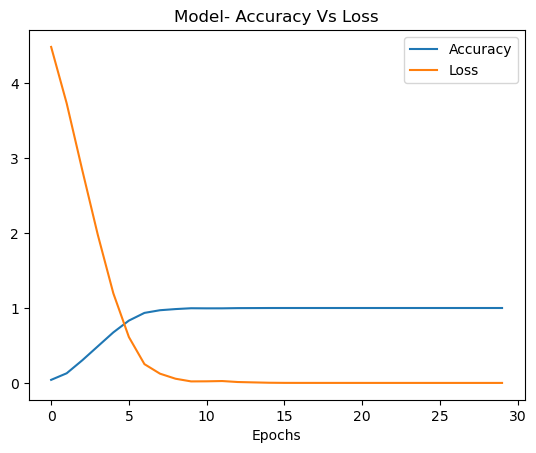

In [17]:
plt.plot(range(len(model.history.history['acc'])),model.history.history['acc'])
plt.plot(range(len(model.history.history['loss'])),model.history.history['loss'])
plt.title('Model- Accuracy Vs Loss')
plt.xlabel('Epochs')
plt.legend(['Accuracy', 'Loss'])
plt.show()

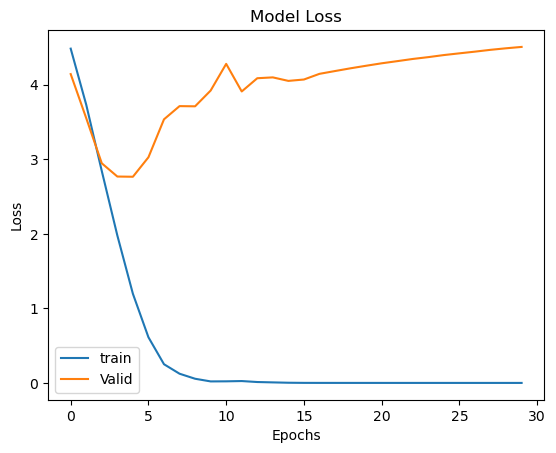

In [18]:
plt.plot(model.history.history['loss'])
plt.plot(model.history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epochs')
plt.legend(['train', 'Valid'])
plt.show()

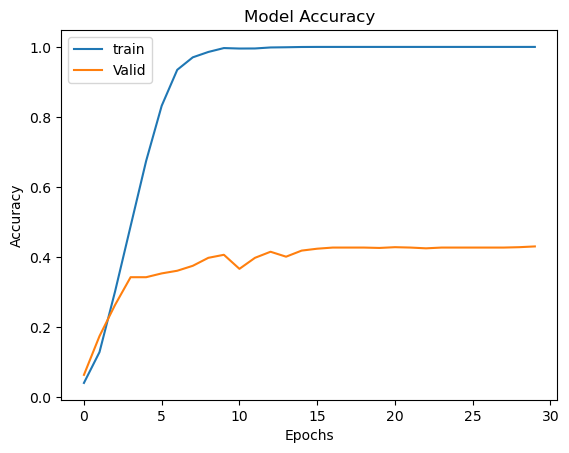

In [19]:
plt.plot(model.history.history['acc'])
plt.plot(model.history.history['val_acc'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.legend(['train', 'Valid'])
plt.show()

In [20]:
pred=model.predict(valx)
print("Predicted Probabilities -\n",pred[:4])
pred_digits=np.argmax(pred,axis=1)
print("\nPredicted Class [Highest Prob] -",pred_digits[:4])

C:\Users\blaks\anaconda3\lib\site-packages\keras\engine\training_v1.py:2359: UserWarning: `Model.state_updates` will be removed in a future version. This property should not be used in TensorFlow 2.0, as `updates` are applied automatically.
  updates=self.state_updates,


Predicted Probabilities -
 [[2.60082568e-04 8.19246707e-05 6.82302052e-05 4.51715756e-03
  1.39019699e-11 1.61335765e-06 2.76602600e-02 3.17663222e-07
  5.12439801e-05 2.69964624e-11 4.54598921e-04 1.51384683e-08
  7.00493925e-04 9.64426022e-07 3.97250158e-13 5.99521677e-09
  3.58007469e-07 5.91769107e-02 2.37411298e-02 2.63971034e-02
  1.94770894e-10 4.91446517e-05 2.15752916e-05 3.21512705e-10
  1.29994238e-04 1.49920278e-13 5.07785813e-08 1.55527886e-07
  1.83484863e-05 1.07134029e-03 5.32182213e-03 1.41822780e-02
  3.62272985e-08 2.55986641e-04 6.10744522e-08 1.69572813e-04
  2.55639851e-03 9.33735428e-05 3.01541993e-04 1.66784783e-04
  2.17687848e-05 1.21303786e-10 1.94862541e-02 2.65983143e-03
  1.91629096e-03 9.63301661e-11 1.80269397e-10 5.96568975e-11
  1.97956178e-05 7.21422144e-10 4.78889346e-01 6.65065658e-04
  1.55100005e-03 5.01662839e-13 6.45176973e-04 3.90636785e-12
  3.23147942e-05 4.29350430e-13 3.18476365e-13 7.53824711e-11
  1.95690468e-08 3.53757851e-03 3.16541168e

In [21]:
i=0
prop_class=[]
mis_class=[]

for i in range(len(valy)):
    if(np.argmax(valy[i])==pred_digits[i]):
        prop_class.append(i)
    if(len(prop_class)==8):
        break

i=0
for i in range(len(valy)):
    if(not np.argmax(valy[i])==pred_digits[i]):
        mis_class.append(i)
    if(len(mis_class)==8):
        break

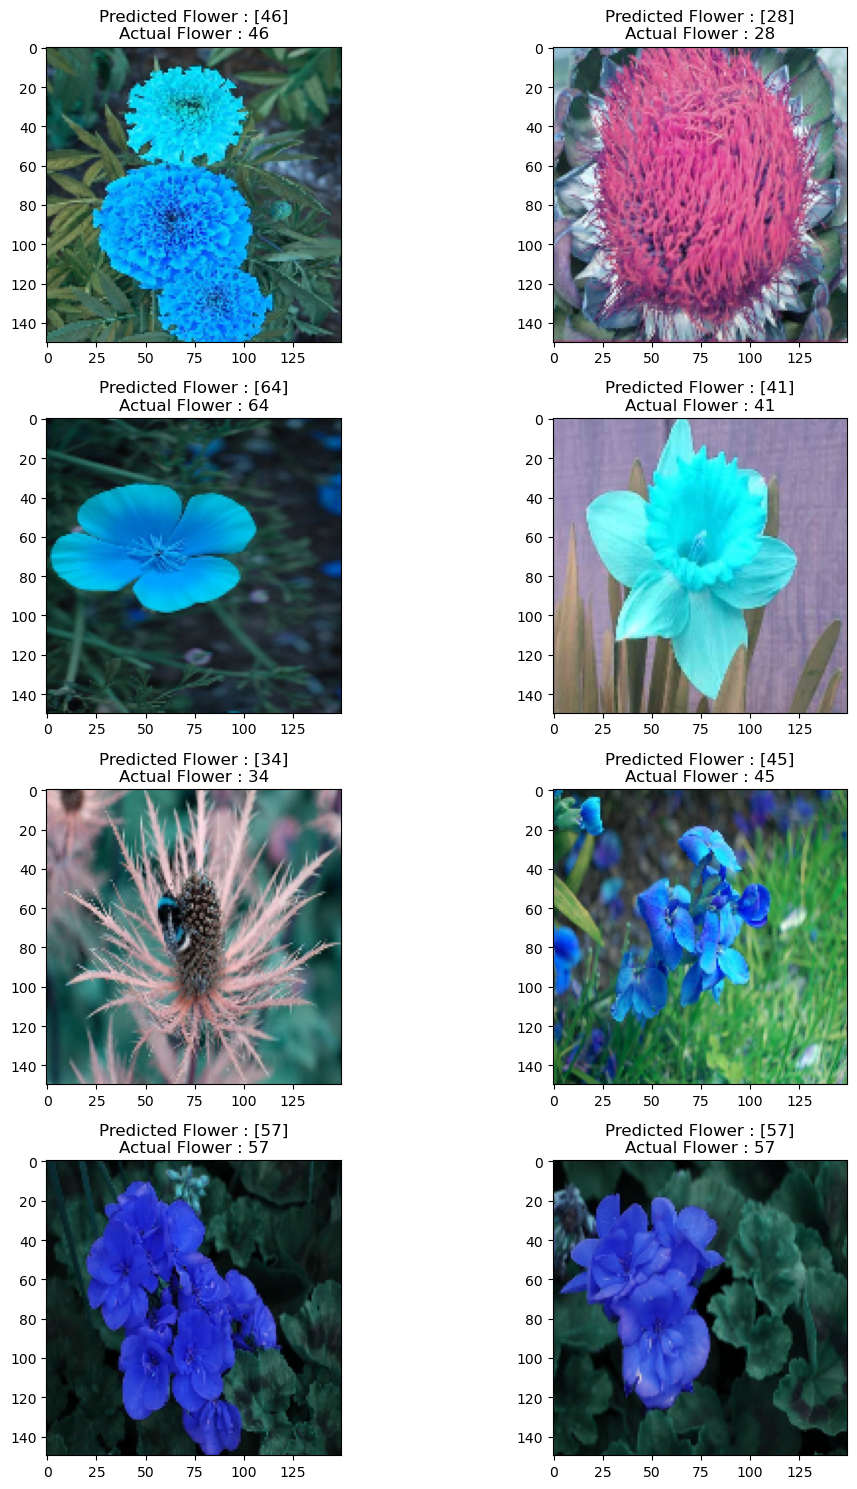

In [22]:
import warnings
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()


warnings.filterwarnings('always')
warnings.filterwarnings('ignore')

count=0
fig,ax=plt.subplots(4,2)
fig.set_size_inches(15,15)
for i in range (4):
    for j in range (2):
        ax[i,j].imshow(valx[prop_class[count]])
        ax[i,j].set_title("Predicted Flower : "+str([pred_digits[prop_class[count]]])+"\n"+"Actual Flower : "+str(np.argmax([valy[prop_class[count]]])))
        plt.tight_layout()
        count+=1

In [55]:
from keras.applications.vgg16 import VGG16

In [56]:
base_model=VGG16(include_top=False, weights=None,input_shape=(150,150,3), pooling='avg')

In [57]:
import os
print(os.listdir('C:/Users/blaks/archive/'))

['vgg16_weights_tf_dim_ordering_tf_kernels_notop.h5']


In [58]:
weights_path='C:/Users/blaks/archive/vgg16_weights_tf_dim_ordering_tf_kernels_notop.h5'

In [59]:
base_model.load_weights(weights_path)


In [60]:
base_model.summary()

Model: "vgg16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 150, 150, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 150, 150, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 150, 150, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 75, 75, 64)        0         
                                                                 
 block2_conv1 (Conv2D)       (None, 75, 75, 128)       73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 75, 75, 128)       147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 37, 37, 128)       0     

In [61]:
from keras import backend as K
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import Adam,SGD,Adagrad,Adadelta,RMSprop
from keras.utils import to_categorical

In [62]:
model=Sequential()
model.add(base_model)
model.add(Dense(512,activation='relu'))
model.add(Dense(64,activation='relu'))
model.add(Dense(4,activation='softmax'))

model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 512)               14714688  
                                                                 
 dense_4 (Dense)             (None, 512)               262656    
                                                                 
 dense_5 (Dense)             (None, 64)                32832     
                                                                 
 dense_6 (Dense)             (None, 4)                 260       
                                                                 
Total params: 15,010,436
Trainable params: 15,010,436
Non-trainable params: 0
_________________________________________________________________


In [63]:
base_model.trainable=True

In [64]:
model.compile(optimizer=Adam(lr=1e-4),loss='categorical_crossentropy',metrics=['accuracy'])

In [65]:
from keras.preprocessing.image import ImageDataGenerator

In [68]:
datagen = ImageDataGenerator(
        featurewise_center=False,  
        samplewise_center=False,  
        featurewise_std_normalization=False,  
        samplewise_std_normalization=False,  
        zca_whitening=False,  
        rotation_range=10,  
        zoom_range = 0.1,  
        width_shift_range=0.2,  
        height_shift_range=0.2,  
        horizontal_flip=True,  
        vertical_flip=False)

In [67]:
History = model.fit_generator(datagen.flow(trainx,trainy, batch_size=batchSize),
                              epochs = 2,use_multiprocessing=True,
                              verbose = 1, steps_per_epoch=trainx.shape[0] // batchSize)

Epoch 1/2


Exception in thread Thread-13:
Traceback (most recent call last):
  File "C:\Users\blaks\anaconda3\lib\threading.py", line 980, in _bootstrap_inner
    self.run()
  File "C:\Users\blaks\anaconda3\lib\threading.py", line 917, in run
    self._target(*self._args, **self._kwargs)
  File "C:\Users\blaks\anaconda3\lib\site-packages\keras\utils\data_utils.py", line 828, in _run
    with closing(self.executor_fn(_SHARED_SEQUENCES)) as executor:
  File "C:\Users\blaks\anaconda3\lib\site-packages\keras\utils\data_utils.py", line 803, in pool_fn
    pool = get_pool_class(True)(
  File "C:\Users\blaks\anaconda3\lib\multiprocessing\context.py", line 119, in Pool
    return Pool(processes, initializer, initargs, maxtasksperchild,
  File "C:\Users\blaks\anaconda3\lib\multiprocessing\pool.py", line 212, in __init__
    self._repopulate_pool()
  File "C:\Users\blaks\anaconda3\lib\multiprocessing\pool.py", line 303, in _repopulate_pool
    return self._repopulate_pool_static(self._ctx, self.Process,
  

KeyboardInterrupt: 

In [ ]:
model.fit(trainx,trainy,batch_size=batchSize,epochs=ep,validation_split=.15)

In [ ]:
model.evaluate(X_test,y_test)